# Data analysis for building Uni-Mea models

## 0. Load

In [1]:
# Trial
import pandas as pd
pd.read_csv('./QMdata4ML/df_elec_x_with_name_fold.csv',index_col=0,nrows=5)

,smiles,elec_sites,elec_names,MAA_values,elec_GCS_3_cm5,Set,elec_SMI2GCS_3_cm5,elec_SMI2GCS_5_cm5,elec_RDKitCountFP_512,elec_RDKitGasteigerGCS_5,...,name,Set_fold1,Set_fold2,Set_fold3,Set_fold4,Set_fold5,Set_scaffold,ScafMaxSim,rdkitAtomWiseFP,MDist
0,NOCc1cccc(I)c1,3,double_bond,90.348433,"[-0.01706, 0.12057, -0.11146, -0.08969, 0.0, -...",Train_fold5,"[-0.00668, 0.12661, -0.09866, -0.09247, 0.0, -...","[-0.00668, 0.12661, -0.09866, -0.09247, 0.0, -...","[4, 0, 4, 5, 2, 3, 0, 4, 3, 6, 0, 6, 4, 1, 0, ...","[-0.01928812973227673, 0.0929936027236162, -0....",...,be19f22ec2fab0c91a64172c5f957a61,train,train,train,train,val,train,1.0,"(6, 1, 1, 3, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, ...",3.671537
1,NOCc1cccc(I)c1,4,double_bond,94.924314,"[-0.08969, -0.01706, -0.08484, 0.09939, 0.0, 0...",Train_fold2,"[-0.09247, -0.00668, -0.07901, 0.0887, 0.0, 0....","[-0.09247, -0.00668, -0.07901, 0.0887, 0.0, 0....","[4, 0, 4, 7, 0, 1, 0, 4, 1, 6, 0, 4, 4, 1, 0, ...","[-0.056572952259338685, -0.01928812973227673, ...",...,be19f22ec2fab0c91a64172c5f957a61,train,val,train,train,train,train,1.0,"(6, 1, 1, 3, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.849856
2,NOCc1cccc(I)c1,5,double_bond,91.330269,"[-0.08484, -0.10499, -0.08969, 0.09122, 0.0, 0...",Train_fold3,"[-0.07901, -0.09933, -0.09247, 0.08588, 0.0, 0...","[-0.07901, -0.09933, -0.09247, 0.08588, 0.0, 0...","[2, 0, 4, 7, 0, 3, 0, 4, 2, 3, 0, 5, 2, 0, 0, ...","[-0.060854479918004876, -0.04882194239545837, ...",...,be19f22ec2fab0c91a64172c5f957a61,train,train,val,train,train,train,1.0,"(6, 1, 1, 3, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.836798
3,NOCc1cccc(I)c1,6,double_bond,102.683928,"[-0.10499, 0.01492, -0.08484, 0.08707, 0.0, 0....",Train_fold1,"[-0.09933, 0.00749, -0.07901, 0.08466, 0.0, 0....","[-0.09933, 0.00749, -0.07901, 0.08466, 0.0, 0....","[0, 0, 5, 6, 0, 3, 0, 4, 2, 1, 0, 7, 3, 0, 0, ...","[-0.04882194239545837, 0.013342809000888595, -...",...,be19f22ec2fab0c91a64172c5f957a61,val,train,train,train,train,train,1.0,"(6, 1, 1, 3, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, ...",22.261193
4,NOCc1cccc(I)c1,7,double_bond,276.204538,"[0.01492, 0.00479, -0.11146, -0.10499, 0.0, 0....",Train_fold3,"[0.00749, 0.01751, -0.09866, -0.09933, 0.0, 0....","[0.00749, 0.01751, -0.09866, -0.09933, 0.0, 0....","[2, 0, 5, 6, 2, 3, 0, 4, 3, 2, 0, 6, 3, 0, 0, ...","[0.013342809000888595, -0.04430373540190993, -...",...,be19f22ec2fab0c91a64172c5f957a61,train,train,val,train,train,train,1.0,"(6, 1, 1, 3, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, ...",36.116963


In [2]:
# Load
df_elec = pd.read_csv('./QMdata4ML/df_elec_x_with_name_fold.csv',index_col=0)
df_nuc  = pd.read_csv('./QMdata4ML/df_nuc_x_with_name_fold.csv',index_col=0)

## 1. Reference split (from the paper written by [Ree et. al.](https://doi.org/10.1039/D4SC07297A))

Basic analysis (count entries and sites for each fold)

In [3]:
print('===Electrophilicity===')
display(df_elec['Set'].value_counts())
display(df_elec.groupby(['Set', 'elec_names']).size().unstack(fill_value=0) )
print('\n===Nucleophilicity===')
display(df_nuc['Set'].value_counts())
display(df_nuc.groupby(['Set', 'nuc_names']).size().unstack(fill_value=0) )

===Electrophilicity===


Train_fold1    90801
Train_fold5    90800
Train_fold2    90800
Train_fold3    90800
Train_fold4    90800
Test           80118
Name: Set, dtype: int64

elec_names,Aldehyde,Amide,Anhydride,Ester,Imine,Iminium,Ketone,Michael acceptor,cation_with_charge_plus1,double_bond,double_bond_neighbouratom_with_charge_plus1,triple_bond
Set,,,,,,,,,,,,
Test,27,1799,3,609,1241,35,524,367,309,74246,284,674
Train_fold1,31,2095,4,698,1409,28,636,407,348,84046,324,775
Train_fold2,35,1973,8,745,1461,22,664,404,319,84103,310,756
Train_fold3,41,2024,2,708,1432,26,653,369,319,84074,350,802
Train_fold4,37,2029,5,715,1383,37,647,400,334,84051,335,827
Train_fold5,38,1996,6,738,1436,26,624,400,326,84133,312,765



===Nucleophilicity===


Train_fold3    110646
Train_fold1    110646
Train_fold2    110646
Train_fold4    110645
Train_fold5    110645
Test            97629
Name: Set, dtype: int64

nuc_names,Aldehyde,Amide,Amine,Carbanion,Carboxylic acid,Ester,Ether,Imine,Isonitrile,Ketone,Nitranion,Nitrile,Phenol,Pyridine_like_nitrogen,anion_with_charge_minus1,atom_with_lone_pair,double_bond,double_bond_neighbouratom_with_charge_plus1,triple_bond
Set,,,,,,,,,,,,,,,,,,,
Test,36,1969,7409,0,306,593,3820,1312,2,656,0,84,611,5042,362,14470,60749,36,172
Train_fold1,49,2189,8383,0,318,688,4219,1440,7,775,0,92,657,5741,438,16671,68759,22,198
Train_fold2,33,2240,8297,0,381,687,4326,1486,9,756,1,83,678,5721,463,16686,68554,39,206
Train_fold3,48,2190,8408,1,383,627,4311,1467,3,789,0,86,686,5737,451,16485,68720,24,230
Train_fold4,43,2242,8259,0,380,641,4283,1452,2,820,0,103,707,5754,446,16577,68674,33,229
Train_fold5,46,2200,8374,1,392,651,4233,1445,4,767,1,89,682,5739,454,16725,68590,27,225


Distribution of target values

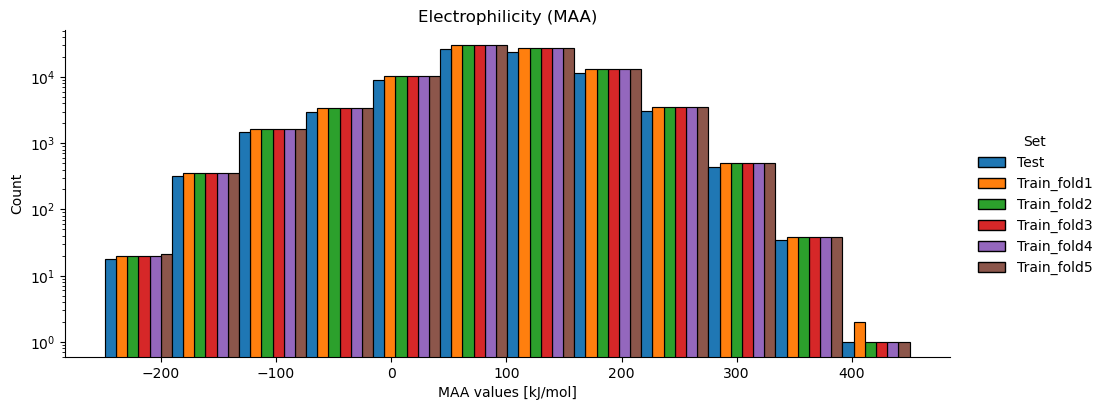

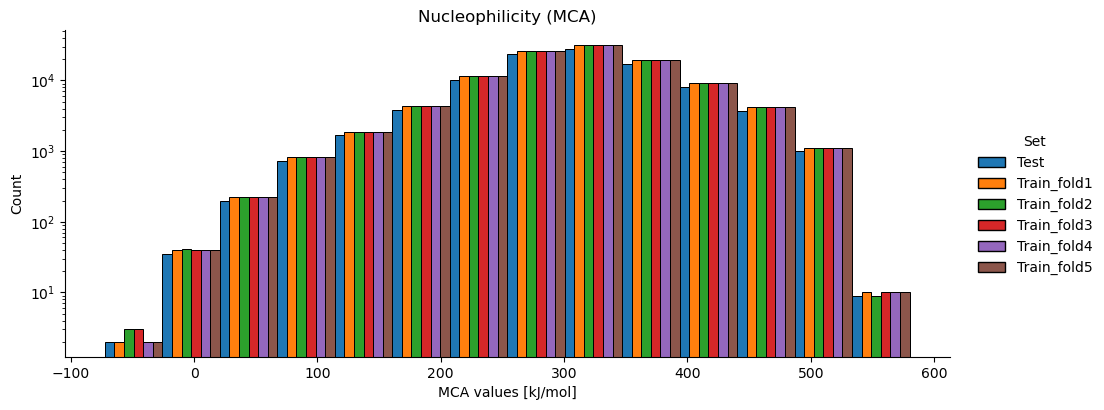

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def roundUpToMultiple(number, multiple):
    num = number + (multiple - 1)
    return num - (num % multiple)

nbins = 13
bins = np.linspace(df_elec['MAA_values'].min(), roundUpToMultiple(df_elec['MAA_values'].max(), 10), nbins)

sns.displot(data=df_elec.sort_values(by='Set'), x='MAA_values', hue='Set', multiple="dodge", alpha=1, bins=bins, height=4, aspect=2.5)
plt.xlabel('MAA values [kJ/mol]')
plt.yscale('log')
plt.title('Electrophilicity (MAA)')
plt.show()

nbins = 15
bins = np.linspace(df_nuc['MCA_values'].min(), roundUpToMultiple(df_nuc['MCA_values'].max(), 10), nbins)

sns.displot(data=df_nuc.sort_values(by='Set'), x='MCA_values', hue='Set', multiple="dodge", alpha=1, bins=bins, height=4, aspect=2.5)
plt.xlabel('MCA values [kJ/mol]')
plt.yscale('log')
plt.title('Nucleophilicity (MCA)')
plt.show()


## 2. Compound-based split

Basic analysis (count entries and sites for each fold)

In [7]:
print('===Electrophilicity===')
display(df_elec['Set_scaffold'].value_counts())
display(df_elec.groupby(['Set_scaffold', 'elec_names']).size().unstack(fill_value=0) )
print('\n===Nucleophilicity===')
display(df_nuc['Set_scaffold'].value_counts())
display(df_nuc.groupby(['Set_scaffold', 'nuc_names']).size().unstack(fill_value=0) )

===Electrophilicity===


train    361605
val       92405
test      80109
Name: Set_scaffold, dtype: int64

elec_names,Aldehyde,Amide,Anhydride,Ester,Imine,Iminium,Ketone,Michael acceptor,cation_with_charge_plus1,double_bond,double_bond_neighbouratom_with_charge_plus1,triple_bond
Set_scaffold,,,,,,,,,,,,
test,25,1920,1,590,1338,20,508,302,340,74095,321,649
train,143,8007,25,2984,5499,121,2562,1704,1271,334863,1258,3168
val,41,1989,2,639,1525,33,678,341,344,85695,336,782



===Nucleophilicity===


train    440645
val      111951
test      98261
Name: Set_scaffold, dtype: int64

nuc_names,Aldehyde,Amide,Amine,Carbanion,Carboxylic acid,Ester,Ether,Imine,Isonitrile,Ketone,Nitranion,Nitrile,Phenol,Pyridine_like_nitrogen,anion_with_charge_minus1,atom_with_lone_pair,double_bond,double_bond_neighbouratom_with_charge_plus1,triple_bond
Set_scaffold,,,,,,,,,,,,,,,,,,,
test,35,2101,7496,0,311,522,3631,1368,4,611,0,81,541,5025,429,15025,60903,21,157
train,171,8736,33412,2,1504,2761,17293,5666,15,3090,1,376,2839,22917,1735,66251,272858,126,892
val,49,2193,8222,0,345,604,4268,1568,8,862,1,80,641,5792,450,16338,70285,34,211


Distribution of target values

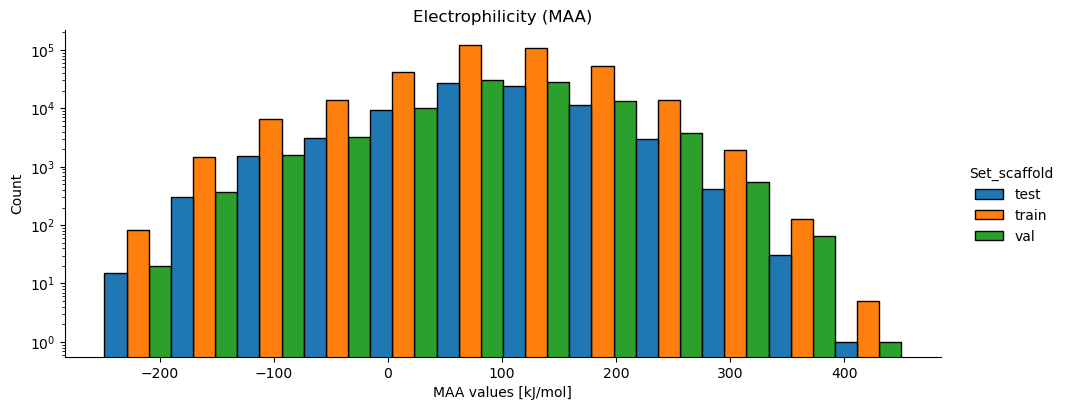

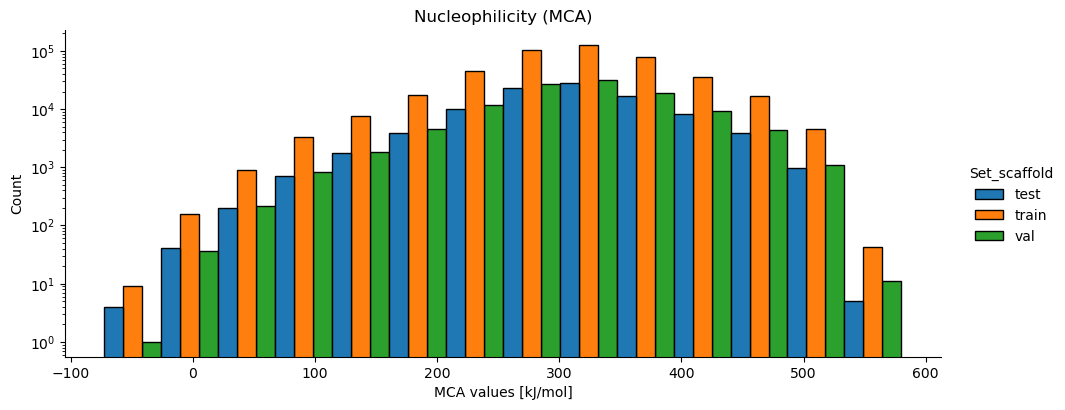

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def roundUpToMultiple(number, multiple):
    num = number + (multiple - 1)
    return num - (num % multiple)

nbins = 13
bins = np.linspace(df_elec['MAA_values'].min(), roundUpToMultiple(df_elec['MAA_values'].max(), 10), nbins)

sns.displot(data=df_elec.sort_values(by='Set_scaffold'), x='MAA_values', hue='Set_scaffold', multiple="dodge", alpha=1, bins=bins, height=4, aspect=2.5)
plt.xlabel('MAA values [kJ/mol]')
plt.yscale('log')
plt.title('Electrophilicity (MAA)')
plt.show()

nbins = 15
bins = np.linspace(df_nuc['MCA_values'].min(), roundUpToMultiple(df_nuc['MCA_values'].max(), 10), nbins)

sns.displot(data=df_nuc.sort_values(by='Set_scaffold'), x='MCA_values', hue='Set_scaffold', multiple="dodge", alpha=1, bins=bins, height=4, aspect=2.5)
plt.xlabel('MCA values [kJ/mol]')
plt.yscale('log')
plt.title('Nucleophilicity (MCA)')
plt.show()
